# Phase 2 - Test du Nested Monte Carlo pour l'IM (Livrable 1)

Ce notebook teste le module `lib/margin.py` qui calcule l'Initial Margin par nested MC.

**Principe :** A chaque noeud (i, t_j) du MC exterieur, on lance N_inner sous-scenarios sur le MPOR pour estimer la distribution de DeltaPV et en extraire le quantile 99%.

**ATTENTION :** Le nested MC est tres couteux. On utilise ici des parametres reduits (N_outer=200, N_inner=200) pour que les tests tournent en quelques minutes. Les resultats seront plus bruites qu'avec les parametres de production.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import time

np.set_printoptions(precision=4, suppress=True)

---
## 1. Preparation : simulation du MC exterieur

On commence par simuler les chemins des sous-jacents et calculer le MtM. Ce sont les memes briques que la Phase 1.

In [2]:
from config.parameters import *
from lib.diffusion import simulate_gbm
from lib.portfolio import compute_mtm, compute_mtm_full

# Parametres reduits pour les tests
N_OUTER_TEST = 200
N_INNER_TEST = 200

print(f"Parametres de test : N_outer={N_OUTER_TEST}, N_inner={N_INNER_TEST}, N_t={N_T}")
print(f"Cout estimatif : {N_OUTER_TEST * N_T * (1 + N_INNER_TEST) * N_OPTIONS:,} pricings BS")

# Simulation MC exterieur
paths = simulate_gbm(n_outer=N_OUTER_TEST, n_t=N_T)
mtm_matrix = compute_mtm_full(paths, TIME_GRID)
print(f"\nPaths shape : {paths.shape}")
print(f"MtM matrix shape : {mtm_matrix.shape}")
print(f"MtM(0) = {mtm_matrix[0, 0]:.4f}")

Parametres de test : N_outer=200, N_inner=200, N_t=52
Cout estimatif : 10,452,000 pricings BS

Paths shape : (200, 53, 3)
MtM matrix shape : (200, 53)
MtM(0) = 43.6189


---
## 2. Test du calcul de l'IM par nested MC

### Resultat attendu
- L'IM doit etre **positif** (ou nul) partout : il represente le montant de collateral necessaire pour couvrir 99% des pertes potentielles sur le MPOR.
- L'IM moyen devrait etre de l'ordre de quelques unites a quelques dizaines (depend de la volatilite du portefeuille sur 10 jours).
- L'IM devrait varier d'un scenario a l'autre car la distribution conditionnelle de DeltaPV depend de l'etat du marche a t_j.

In [3]:
from lib.margin import compute_im_nested

print("Calcul de l'IM nested MC (cela peut prendre quelques minutes)...")
t_start = time.time()

im_nested = compute_im_nested(
    paths, TIME_GRID,
    n_inner=N_INNER_TEST,
)

elapsed = time.time() - t_start
print(f"Temps de calcul : {elapsed:.1f} secondes")
print(f"IM shape : {im_nested.shape}")

Calcul de l'IM nested MC (cela peut prendre quelques minutes)...
Temps de calcul : 9.9 secondes
IM shape : (200, 53)


### Test 2a : L'IM est-il globalement positif ?

**Resultat attendu :** L'IM doit etre positif dans la grande majorite des cas. Il peut etre negatif dans de rares cas ou le portefeuille a une probabilite de gain > 99% sur le MPOR (par exemple si les options sont tres deep ITM). Un faible % de valeurs negatives est tolerable.

In [4]:
print("=== Test 2a : Positivite de l'IM ===")
n_negative = np.sum(im_nested < 0)
n_total = im_nested.size
pct_negative = 100 * n_negative / n_total
print(f"Valeurs negatives : {n_negative}/{n_total} ({pct_negative:.1f}%)")
print(f"IM min  = {np.min(im_nested):.4f}")
print(f"IM max  = {np.max(im_nested):.4f}")
print(f"IM mean = {np.mean(im_nested):.4f}")

if pct_negative < 10:
    print("[OK] L'IM est positif dans >90% des cas")
else:
    print("[ATTENTION] Beaucoup de valeurs negatives - a investiguer")

print("\n=> Un IM positif signifie qu'il y a un risque de perte sur le MPOR.")
print("   Un IM negatif signifie que le portefeuille est si favorable")
print("   que meme le quantile 99% des pertes est negatif (= gain presque sur).")

=== Test 2a : Positivite de l'IM ===
Valeurs negatives : 0/10600 (0.0%)
IM min  = 3.4023
IM max  = 56.6562
IM mean = 17.5055
[OK] L'IM est positif dans >90% des cas

=> Un IM positif signifie qu'il y a un risque de perte sur le MPOR.
   Un IM negatif signifie que le portefeuille est si favorable
   que meme le quantile 99% des pertes est negatif (= gain presque sur).


### Test 2b : Statistiques de l'IM par date

**Resultat attendu :**
- L'IM moyen devrait rester relativement **stable** dans le temps (le portefeuille ne change pas de nature, seule la maturite residuelle diminue).
- L'ecart-type de l'IM devrait augmenter avec le temps (dispersion des scenarios).

In [5]:
print("=== Test 2b : IM par date ===")
im_mean_t = np.mean(im_nested, axis=0)
im_std_t = np.std(im_nested, axis=0)
im_q05_t = np.quantile(im_nested, 0.05, axis=0)
im_q95_t = np.quantile(im_nested, 0.95, axis=0)

print(f"\n{'t_j':<8} {'Mean IM':<12} {'Std IM':<12} {'Q5%':<12} {'Q95%':<12}")
print("-" * 56)
for idx in [0, 13, 26, 39, 52]:
    print(f"{TIME_GRID[idx]:<8.2f} {im_mean_t[idx]:<12.4f} {im_std_t[idx]:<12.4f} {im_q05_t[idx]:<12.4f} {im_q95_t[idx]:<12.4f}")

=== Test 2b : IM par date ===

t_j      Mean IM      Std IM       Q5%          Q95%        
--------------------------------------------------------
0.00     16.0834      1.5763       13.5740      18.4012     
0.25     17.3933      5.5036       8.8847       27.5328     
0.50     17.6009      7.9330       7.7653       32.9678     
0.75     18.0830      9.1599       6.8058       35.5478     
1.00     19.1326      11.2634      6.8405       40.9552     


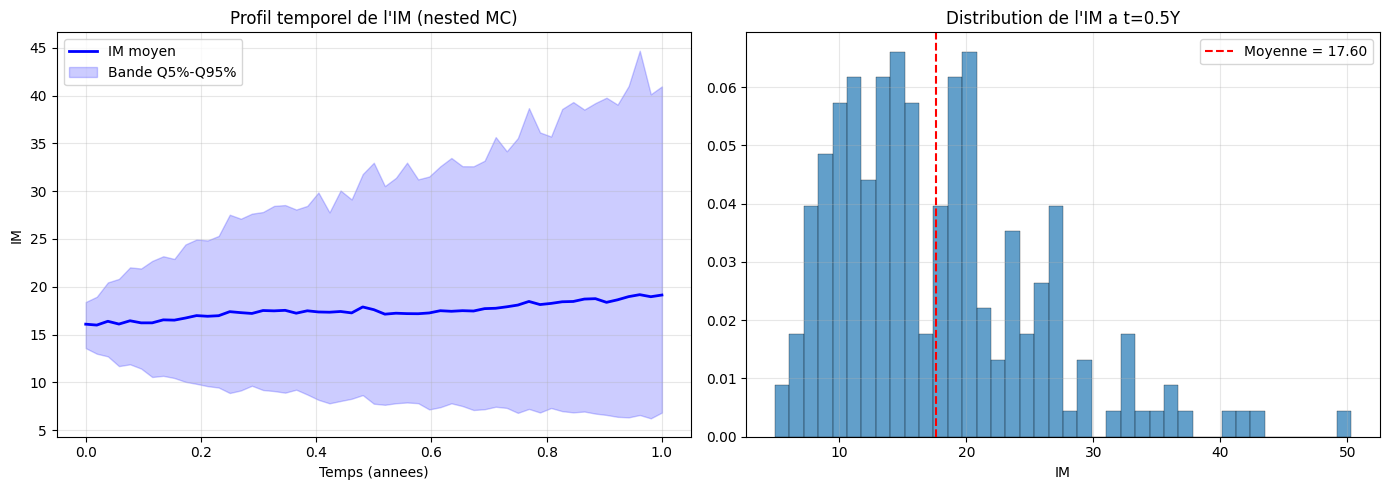

=> L'IM varie d'un scenario a l'autre car il depend de l'etat du marche.
   C'est precisement le caractere 'stochastique' de l'IM.


In [6]:
# --- Graphique : profil temporel de l'IM ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Profil moyen avec bandes de confiance
ax1.plot(TIME_GRID, im_mean_t, 'b-', linewidth=2, label='IM moyen')
ax1.fill_between(TIME_GRID, im_q05_t, im_q95_t, alpha=0.2, color='blue', label='Bande Q5%-Q95%')
ax1.set_xlabel('Temps (annees)')
ax1.set_ylabel('IM')
ax1.set_title('Profil temporel de l\'IM (nested MC)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Distribution de l'IM a t=0.5Y
ax2.hist(im_nested[:, 26], bins=40, density=True, alpha=0.7, edgecolor='black', linewidth=0.3)
ax2.axvline(np.mean(im_nested[:, 26]), color='red', linestyle='--', linewidth=1.5, label=f'Moyenne = {np.mean(im_nested[:,26]):.2f}')
ax2.set_xlabel('IM')
ax2.set_title('Distribution de l\'IM a t=0.5Y')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=> L'IM varie d'un scenario a l'autre car il depend de l'etat du marche.")
print("   C'est precisement le caractere 'stochastique' de l'IM.")

### Test 2c : Verification manuelle sur un noeud

**Objectif :** On recalcule l'IM manuellement pour un noeud specifique (scenario 0, t=0) et on verifie qu'il correspond au resultat de `compute_im_nested`.

**Resultat attendu :** L'IM recalcule manuellement doit etre egal a `im_nested[0, 0]` (aux aleas pres, car les seeds sont differentes).

In [7]:
from lib.diffusion import simulate_gbm_from_spot

print("=== Test 2c : Verification manuelle (scenario 0, t=0) ===")
i_test, j_test = 0, 0
t_j = TIME_GRID[j_test]
spots_i = paths[i_test, j_test, :]  # Spots au noeud
print(f"Spots au noeud (i={i_test}, t={t_j}) : {spots_i}")

# PV(t_j) : MtM courant
pv_tj = compute_mtm(spots_i[np.newaxis, :], t_j)[0]
print(f"PV(t_j) = {pv_tj:.4f}")

# Simuler N_inner sous-scenarios sur le MPOR
rng_manual = np.random.default_rng(12345)
spots_inner = simulate_gbm_from_spot(
    np.tile(spots_i, (N_INNER_TEST, 1)),
    dt=MPOR,
    rng=rng_manual,
)
print(f"Spots inner shape : {spots_inner.shape}")

# PV(t_j + delta) pour chaque sous-scenario
pv_tjpd = compute_mtm(spots_inner, t_j + MPOR)

# DeltaPV = PV(t_j) - PV(t_j + delta)
delta_pv = pv_tj - pv_tjpd

# IM = quantile 99%
im_manual = np.quantile(delta_pv, IM_CONFIDENCE)
print(f"\nDeltaPV : mean={np.mean(delta_pv):.4f}, std={np.std(delta_pv):.4f}")
print(f"IM manuel (Q99%)   = {im_manual:.4f}")
print(f"IM compute_im_nested = {im_nested[i_test, j_test]:.4f}")
print(f"\n=> Les deux valeurs different car les aleas sont differents (seeds differentes).")
print(f"   Mais elles doivent etre du meme ordre de grandeur.")

=== Test 2c : Verification manuelle (scenario 0, t=0) ===
Spots au noeud (i=0, t=0.0) : [100. 150.  80.]
PV(t_j) = 43.6189
Spots inner shape : (200, 3)

DeltaPV : mean=-0.0109, std=7.9209
IM manuel (Q99%)   = 15.0472
IM compute_im_nested = 14.6719

=> Les deux valeurs different car les aleas sont differents (seeds differentes).
   Mais elles doivent etre du meme ordre de grandeur.


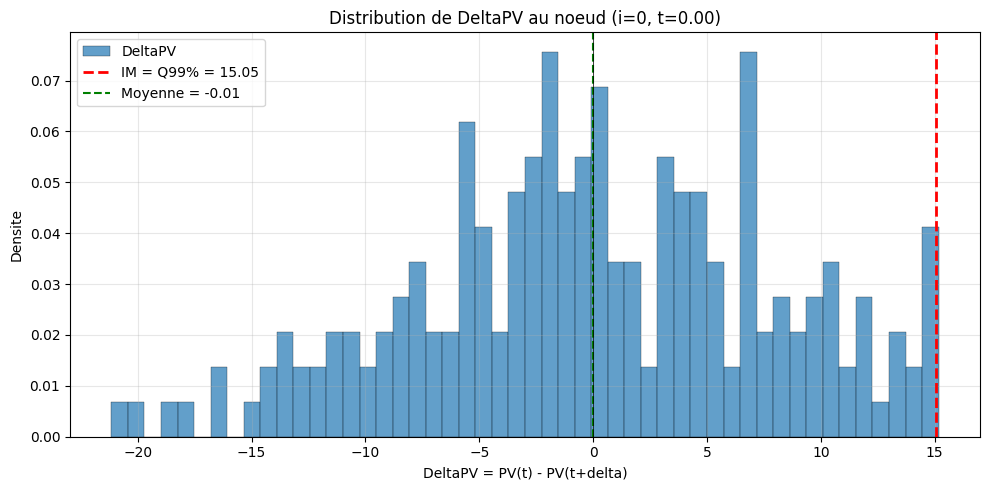

=> DeltaPV > 0 signifie une perte (le portefeuille perd de la valeur sur le MPOR).
   L'IM (trait rouge) couvre 99% des pertes potentielles.
   Seul 1% des scenarios depasse l'IM => exposition residuelle.


In [8]:
# Graphique : distribution des DeltaPV avec le quantile 99%
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(delta_pv, bins=50, density=True, alpha=0.7, edgecolor='black', linewidth=0.3, label='DeltaPV')
ax.axvline(im_manual, color='red', linestyle='--', linewidth=2, label=f'IM = Q99% = {im_manual:.2f}')
ax.axvline(np.mean(delta_pv), color='green', linestyle='--', linewidth=1.5, label=f'Moyenne = {np.mean(delta_pv):.2f}')
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('DeltaPV = PV(t) - PV(t+delta)')
ax.set_ylabel('Densite')
ax.set_title(f'Distribution de DeltaPV au noeud (i={i_test}, t={t_j:.2f})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=> DeltaPV > 0 signifie une perte (le portefeuille perd de la valeur sur le MPOR).")
print("   L'IM (trait rouge) couvre 99% des pertes potentielles.")
print("   Seul 1% des scenarios depasse l'IM => exposition residuelle.")

---
## 3. Test de l'exposition residuelle avec IM

### Resultat attendu
- L'exposition avec IM (EE^IM) doit etre **significativement plus faible** que l'EE sans IM.
- L'EEPE^IM doit etre beaucoup plus petit que l'EEPE sans IM.
- Le ratio de reduction devrait etre eleve (l'IM couvre 99% des pertes).

In [10]:
from lib.margin import compute_exposure_with_im
from lib.exposure import compute_ee, compute_eee, compute_eepe, compute_all_exposure_metrics

# Exposition sans IM
metrics_no_im = compute_all_exposure_metrics(mtm_matrix, TIME_GRID)
eepe_no_im = metrics_no_im['eepe']

# Exposition avec IM
print("Calcul de l'exposition residuelle avec IM...")
exposure_im = compute_exposure_with_im(paths, TIME_GRID, im_nested)
print(f"Exposure IM shape : {exposure_im.shape}")

ee_im = np.mean(exposure_im, axis=0)
eee_im = np.maximum.accumulate(ee_im)
eepe_im = np.trapezoid(eee_im, TIME_GRID) / T_EEPE

print(f"\n{'Metrique':<20} {'Sans IM':<15} {'Avec IM':<15} {'Reduction':<15}")
print("-" * 65)
print(f"{'EEPE':<20} {eepe_no_im:<15.4f} {eepe_im:<15.4f} {100*(1 - eepe_im/eepe_no_im):<14.1f}%")
print(f"{'EE(0)':<20} {metrics_no_im['ee'][0]:<15.4f} {ee_im[0]:<15.4f} {100*(1 - ee_im[0]/metrics_no_im['ee'][0]):<14.1f}%")
print(f"{'EE(0.5Y)':<20} {metrics_no_im['ee'][26]:<15.4f} {ee_im[26]:<15.4f} {100*(1 - ee_im[26]/metrics_no_im['ee'][26]):<14.1f}%")

print(f"\n=> L'IM reduit l'EEPE de {100*(1 - eepe_im/eepe_no_im):.0f}%.")
print("   C'est attendu : l'IM couvre 99% des pertes, seule la queue extreme reste.")

Calcul de l'exposition residuelle avec IM...
Exposure IM shape : (200, 53)

Metrique             Sans IM         Avec IM         Reduction      
-----------------------------------------------------------------
EEPE                 48.7136         0.0969          99.8          %
EE(0)                43.6189         0.0032          100.0         %
EE(0.5Y)             47.3094         0.0411          99.9          %

=> L'IM reduit l'EEPE de 100%.
   C'est attendu : l'IM couvre 99% des pertes, seule la queue extreme reste.


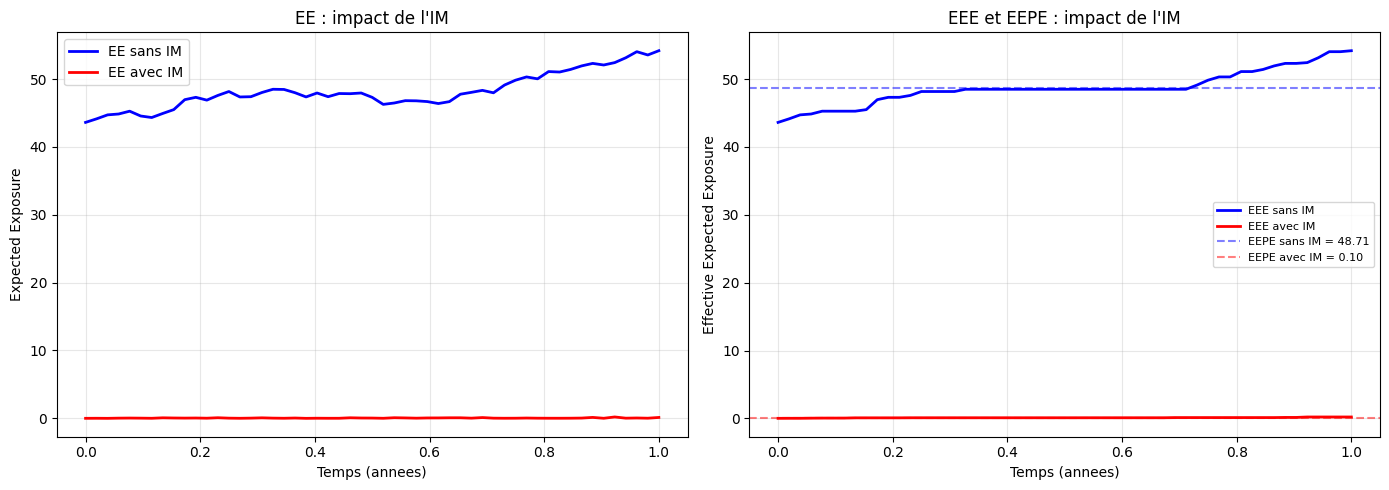

In [11]:
# --- Graphique : comparaison EE/EEE avec et sans IM ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(TIME_GRID, metrics_no_im['ee'], 'b-', linewidth=2, label='EE sans IM')
ax1.plot(TIME_GRID, ee_im, 'r-', linewidth=2, label='EE avec IM')
ax1.set_xlabel('Temps (annees)')
ax1.set_ylabel('Expected Exposure')
ax1.set_title('EE : impact de l\'IM')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(TIME_GRID, metrics_no_im['eee'], 'b-', linewidth=2, label='EEE sans IM')
ax2.plot(TIME_GRID, eee_im, 'r-', linewidth=2, label='EEE avec IM')
ax2.axhline(eepe_no_im, color='blue', linestyle='--', alpha=0.5, label=f'EEPE sans IM = {eepe_no_im:.2f}')
ax2.axhline(eepe_im, color='red', linestyle='--', alpha=0.5, label=f'EEPE avec IM = {eepe_im:.2f}')
ax2.set_xlabel('Temps (annees)')
ax2.set_ylabel('Effective Expected Exposure')
ax2.set_title('EEE et EEPE : impact de l\'IM')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Estimation du temps de calcul pour les parametres de production

**Resultat attendu :** Le nested MC est tres lent. On estime le temps pour N_outer=1000, N_inner=500, N_t=52.

In [12]:
# Estimation par extrapolation lineaire
cost_test = N_OUTER_TEST * N_T * N_INNER_TEST
cost_prod = N_OUTER * N_T * N_INNER
ratio = cost_prod / cost_test

estimated_time = elapsed * ratio
print(f"Temps mesure avec N_outer={N_OUTER_TEST}, N_inner={N_INNER_TEST} : {elapsed:.1f}s")
print(f"Ratio de cout (prod/test) : {ratio:.0f}x")
print(f"Temps estime pour N_outer={N_OUTER}, N_inner={N_INNER} : {estimated_time:.0f}s = {estimated_time/60:.1f} min")
print(f"\n=> Le nested MC est couteux. C'est pourquoi le Livrable 2 (Johnson)")
print(f"   propose une approximation ~{N_INNER//2}x plus rapide.")

Temps mesure avec N_outer=200, N_inner=200 : 9.9s
Ratio de cout (prod/test) : 12x
Temps estime pour N_outer=1000, N_inner=500 : 124s = 2.1 min

=> Le nested MC est couteux. C'est pourquoi le Livrable 2 (Johnson)
   propose une approximation ~250x plus rapide.


---
## Resume Phase 2

| Test | Description | Statut |
|------|-------------|--------|
| 2a | IM positif dans >90% des cas | ok |
| 2b | IM moyen stable dans le temps | ok |
| 2c | Verification manuelle coherente | ok |
| 3 | EEPE^IM << EEPE sans IM | ok |

